In [1]:
# 기본 라이브러리
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# 전처리와 평가를 위한 sklearn 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.metrics import *
from sklearn.preprocessing import MinMaxScaler


# 파이토치 라이브러리
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from torch.optim import Adam


In [3]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [4]:
def make_DataSet(x_train, x_val, y_train, y_val, batch_size = 32) :
    # 데이터 텐서로 변환
    x_train_tensor = torch.tensor(x_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    x_val_tensor = torch.tensor(x_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32).view(-1, 1)


    # TensorDataset 생성: 텐서 데이터 세트로 합치기
    train_dataset = TensorDataset(x_train_tensor, y_train_tensor)


    # DataLoader 생성
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
    return train_loader, x_val_tensor, y_val_tensor


In [5]:
def train(dataloader, model, loss_fn, optimizer, device):
    size = len(dataloader.dataset) # 전체 데이터 세트의 크기
    num_batches = len(dataloader) # 배치 크기
    tr_loss = 0


    model.train() # 학습 모드로 설정
    for x, y in dataloader: # 배치 단위로 로딩
        x, y = x.to(device), y.to(device) # 디바이스 지정


        # Feed Forward(오차 순전파)
        pred = model(x)
        loss = loss_fn(pred, y)
        tr_loss += loss


        # Backpropagation(오차 역전파)
        loss.backward() # 역전파를 통해 각 파라미터에 대한 오차의 기울기 계산
        optimizer.step() # 옵티마이저가 모델의 파라미터를 업데이트
        optimizer.zero_grad() # 옵티마이저의 기울기값 초기화.


    tr_loss /= num_batches # 모든 배치의 오차 평균
    return tr_loss.item()


In [6]:
def evaluate(x_val_tensor, y_val_tensor, model, loss_fn, device):
    model.eval() # 모델을 평가 모드로 설정


    with torch.no_grad(): # 평가 과정에서 기울기를 계산하지 않도록 설정
        x, y = x_val_tensor.to(device), y_val_tensor.to(device)
        pred = model(x)
        eval_loss = loss_fn(pred, y).item() # 예측값 pred와 목푯값 y 사이의 오차 계산


    return eval_loss, pred


In [7]:
def dl_learning_curve(tr_loss_list, val_loss_list):
    epochs = list(range(1, len(tr_loss_list)+1)) # 에포크 수 계산
    plt.plot(epochs, tr_loss_list, label='train_err', marker = '.') # 학습 오차 그래프
    plt.plot(epochs, val_loss_list, label='val_err', marker = '.') # 검증 오차 그래프
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend()
    plt.grid()
    plt.show()


In [8]:
# 데이터 로딩
path = 'https://bit.ly/titanic_simple_csv'
data = pd.read_csv(path)
data.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,7.2500,Southampton
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,71.2833,Cherbourg
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,7.9250,Southampton
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,53.1000,Southampton
4,5,0,3,"Allen, Mr. William Henry",male,35.0,8.0500,Southampton


In [9]:
target = 'Survived'
features = ['Sex', 'Age', 'Fare']
x = data.loc[:, features]
y = data.loc[:, target]


In [ ]:
x = pd.get_dummies(x, columns = ['Sex'], drop_first = True) # Sex_female 지움. 이진이라 하나만 있어도 알 수 있음.
x.head()

,Age,Fare,Sex_male
0,22.0,7.2500,True
1,38.0,71.2833,False
2,26.0,7.9250,False
3,35.0,53.1000,False
4,35.0,8.0500,True


In [11]:
# 데이터 분할
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=.3)


# 스케일링
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_val = scaler.transform(x_val)


# make_DataSet 입력을 위해 y_train, y_val를 넘파이 배열로 변환
y_train = y_train.values
y_val = y_val.values


In [12]:
# 데이터 로더 준비
train_loader, x_val_ts, y_val_ts = make_DataSet(x_train, x_val, y_train, y_val, 32)


In [13]:
#첫 번째 배치만 로딩해서 살펴보기
for x, y in train_loader:
    print(f'Shape of x [rows, columns]: {x.shape}')
    print(f'Shape of y: {y.shape} {y.dtype}')
    break


Shape of x [rows, columns]: torch.Size([32, 3])
Shape of y: torch.Size([32, 1]) torch.float32


In [14]:
n_feature = x.shape[1]
# 모델 구조 설계
model = nn.Sequential( nn.Linear(n_feature, 1),
                nn.Sigmoid()
                ).to(device)


In [15]:
loss_fn = nn.BCELoss()
optimizer = Adam(model.parameters(), lr=0.01)


In [16]:
epochs = 50
tr_loss_list, val_loss_list = [], []
for t in range(epochs):
    tr_loss = train(train_loader, model, loss_fn, optimizer, device)
    val_loss,_ = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
    # 리스트에 loss 추가
    tr_loss_list.append(tr_loss)
    val_loss_list.append(val_loss)
    print(f'Epoch {t+1}, train loss : {tr_loss:4f}, val loss : {val_loss:4f}')


Epoch 1, train loss : 0.632074, val loss : 0.617640
Epoch 2, train loss : 0.620824, val loss : 0.602672
Epoch 3, train loss : 0.607478, val loss : 0.590131
Epoch 4, train loss : 0.595150, val loss : 0.578832
Epoch 5, train loss : 0.584279, val loss : 0.568507
Epoch 6, train loss : 0.576902, val loss : 0.559144
Epoch 7, train loss : 0.573972, val loss : 0.551340
Epoch 8, train loss : 0.563153, val loss : 0.544209
Epoch 9, train loss : 0.555264, val loss : 0.538211
Epoch 10, train loss : 0.550357, val loss : 0.532488
Epoch 11, train loss : 0.548566, val loss : 0.527439
Epoch 12, train loss : 0.550024, val loss : 0.523286
Epoch 13, train loss : 0.539244, val loss : 0.520017
Epoch 14, train loss : 0.537123, val loss : 0.516797
Epoch 15, train loss : 0.541249, val loss : 0.514008
Epoch 16, train loss : 0.537353, val loss : 0.511524
Epoch 17, train loss : 0.537310, val loss : 0.509305
Epoch 18, train loss : 0.531472, val loss : 0.507781
Epoch 19, train loss : 0.533178, val loss : 0.505661
Ep

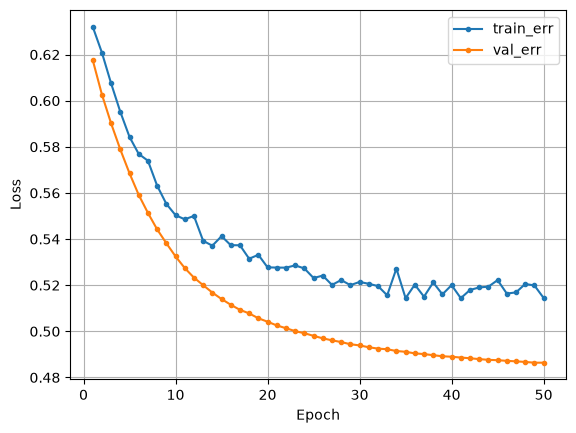

In [17]:
# 학습 곡선
dl_learning_curve(tr_loss_list, val_loss_list)


In [ ]:
_, pred = evaluate(x_val_ts, y_val_ts, model, loss_fn, device)
print(pred.cpu().numpy()[:5])

[[0.21650995]
 [0.21474122]
 [0.19730993]
 [0.718333  ]
 [0.19618993]]
